# Initial exploratory data analysis and preprocessing for GSE155698.
Dataset retreived from: https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE155698 \
Datset name: Multimodal Mapping of the Tumor and Peripheral Blood Immune Landscape in Human Pancreatic Cancer

Similar to GSE212966 dataset, we will run for only the first tumor sample (PDAC1). 

First sample: GSM4710689	PDAC_TISSUE_1

In [1]:
import os

In [2]:
os.getcwd()

'/Users/iriskwon/Documents/CompGenFinalProject'

In [4]:
path = '/Users/iriskwon/Downloads/PDAC_TISSUE_1/filtered_feature_bc_matrix'
os.chdir(path)
files = os.listdir()
print(files)

['features.tsv.gz', 'barcodes.tsv.gz', 'matrix.mtx.gz']


### Preprocessing each sample scRNA-seq

The first sample is a PDAC1 (tumor sample)!

In [5]:
import scanpy as sc 
import pandas as pd 

matrix = 'matrix.mtx.gz'
genes = 'features.tsv.gz'
barcodes = 'barcodes.tsv.gz'

adata = sc.read_mtx(matrix).T  # cells × genes

In [6]:
adata # sample as adatas[0]

AnnData object with n_obs × n_vars = 1633 × 32738

In [7]:
genes_df = pd.read_csv(genes, header=None, sep='\t')
barcodes_df = pd.read_csv(barcodes, header=None)

adata.var_names = genes_df[1].values  # gene symbols
adata.obs_names = barcodes_df[0].values

adata.var_names_make_unique()

In [8]:
genes_df.iloc[:,2].unique()

array(['Gene Expression'], dtype=object)

In [9]:
adata.obs['gsm'] = 'GSM4710689'
adata.obs['sample'] = 'PDAC1'
adata.obs['condition'] = 'PDAC'

In [10]:
print(adata.shape)

(1633, 32738)


In [11]:
print(adata.var_names[:20])

Index(['MIR1302-10', 'FAM138A', 'OR4F5', 'RP11-34P13.7', 'RP11-34P13.8',
       'AL627309.1', 'RP11-34P13.14', 'RP11-34P13.9', 'AP006222.2',
       'RP4-669L17.10', 'OR4F29', 'RP4-669L17.2', 'RP5-857K21.15',
       'RP5-857K21.1', 'RP5-857K21.2', 'RP5-857K21.3', 'RP5-857K21.4',
       'RP5-857K21.5', 'OR4F16', 'RP11-206L10.3'],
      dtype='object')


### QC for the first sample 

In [12]:
# Check mitochondrial genes 
adata.var_names = adata.var_names.str.upper()
adata.var['mt'] = adata.var_names.str.startswith('MT-')

print(sum(adata.var['mt'])) # 13 mitochondrial genes 

13


In [13]:
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
print(sum(adata.var["ribo"])) # 103 ribosomal genes 

106


In [14]:
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")
print(sum(adata.var['hb'])) # 13 hemoglobin genes 

13


In [15]:
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [17]:
adata.var_names_make_unique()

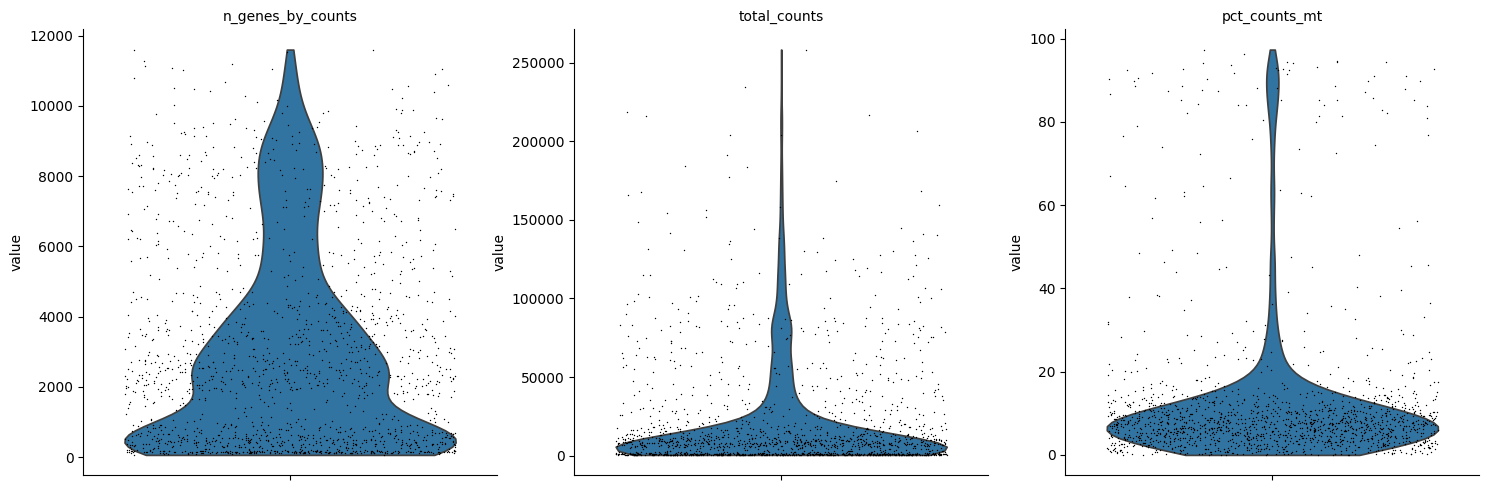

In [18]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

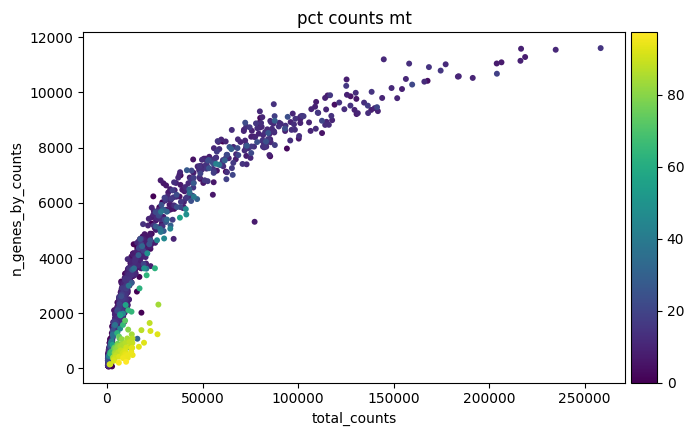

In [19]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")


In [20]:
adata.obs[['n_genes_by_counts', 'total_counts', 'pct_counts_mt']].mean()

n_genes_by_counts     2924.679731
total_counts         20213.140625
pct_counts_mt           12.083760
dtype: float64

In [21]:
adata.obs['total_counts'].describe()

count      1633.000000
mean      20213.140625
std       33963.355469
min         500.000000
25%        1137.000000
50%        7708.000000
75%       18003.000000
max      258349.000000
Name: total_counts, dtype: float64

In [22]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

In [23]:
sc.pp.scrublet(adata, batch_key="sample")

In [24]:
adata = adata[adata.obs.n_genes_by_counts > 300, :]
adata = adata[adata.obs.n_genes_by_counts < 5000, :]

adata = adata[adata.obs.total_counts > 1000, :]
adata = adata[adata.obs.total_counts < 25000, :]

adata = adata[adata.obs.pct_counts_mt < 15, :]

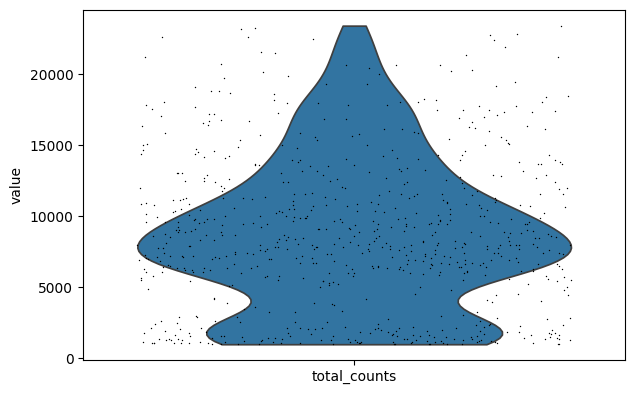

In [25]:
sc.pl.violin(adata, ['total_counts'], jitter=0.4)

In [26]:
adata.layers['counts'] = adata.X.copy() # save counts (before norm)

/var/folders/jc/r13c712s6dj2g5bnkv832wk40000gn/T/ipykernel_24223/374595293.py:1: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  adata.layers['counts'] = adata.X.copy() # save counts (before norm)


In [27]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [28]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

In [29]:
# keep only the HVGs 
adata = adata[:, adata.var.highly_variable]

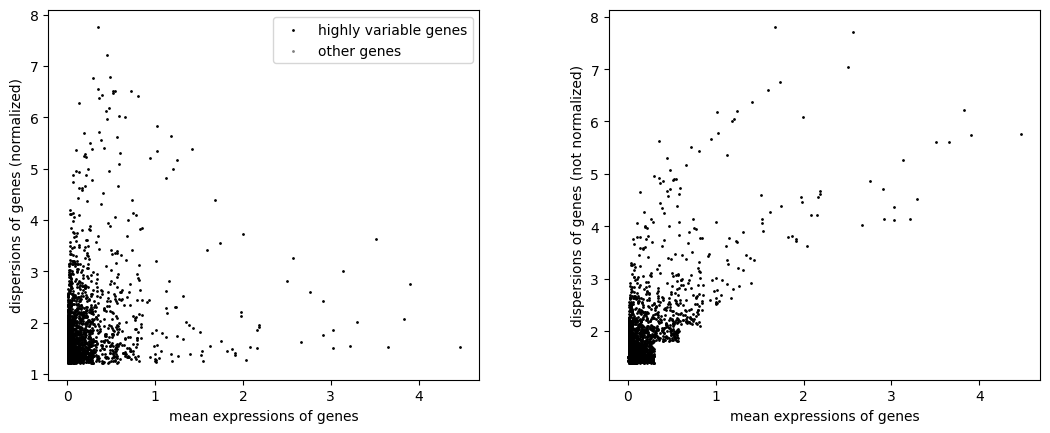

In [30]:
sc.pl.highly_variable_genes(adata)

In [31]:
sc.pp.scale(adata, max_value=10)

/Users/iriskwon/.local/share/virtualenvs/STalign-hu3yymDJ/lib/python3.12/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/Users/iriskwon/miniforge3/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [32]:
sc.tl.pca(adata, svd_solver='arpack')

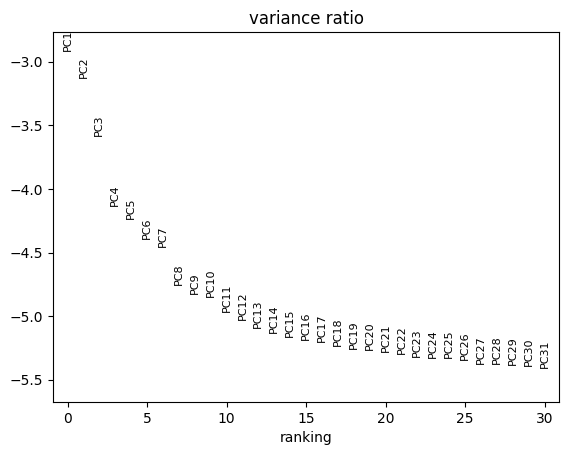

In [33]:
sc.pl.pca_variance_ratio(adata, log=True)

In [36]:
adata.var_keys

<bound method AnnData.var_keys of AnnData object with n_obs × n_vars = 732 × 2000
    obs: 'gsm', 'sample', 'condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'scrublet', 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'sample_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'>

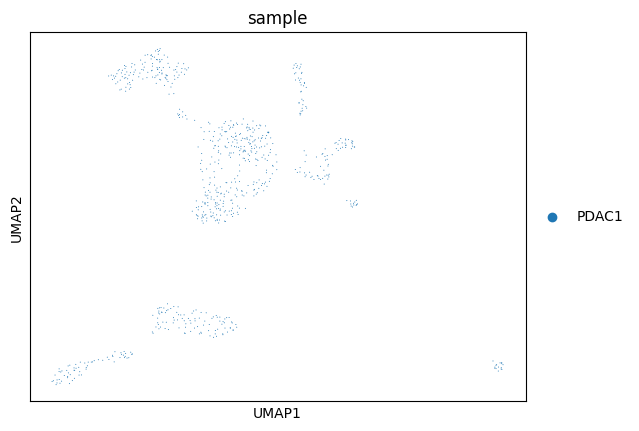

In [34]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=30)
sc.tl.umap(adata)
sc.pl.umap(
    adata,
    color="sample",
    # Setting a smaller point size to get prevent overlap
    size=2,
)

/var/folders/jc/r13c712s6dj2g5bnkv832wk40000gn/T/ipykernel_24223/1689658786.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=r, key_added=f'leiden_{r}')


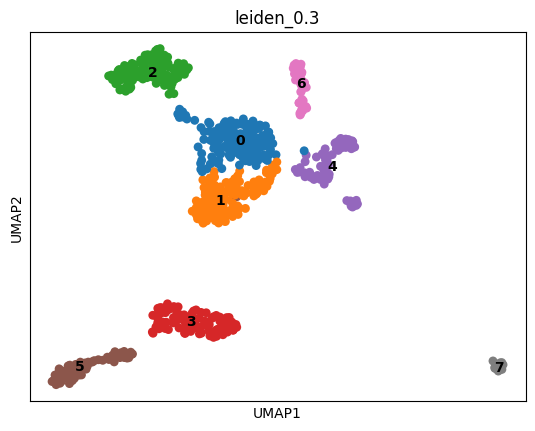

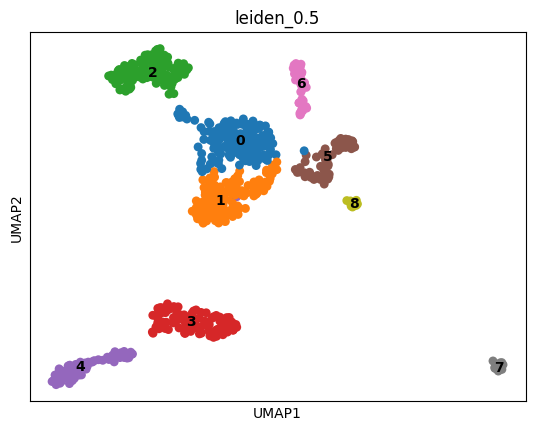

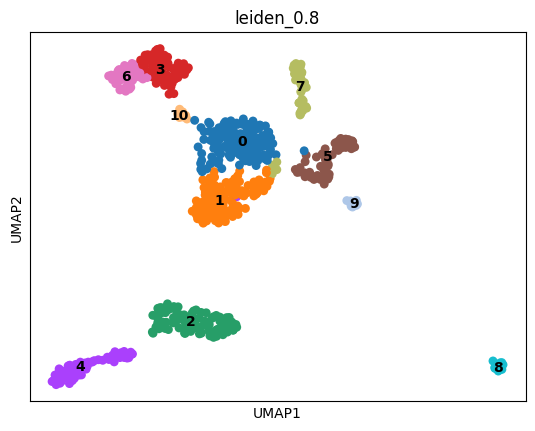

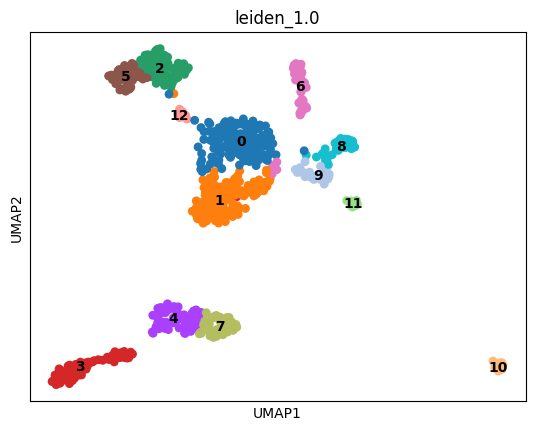

In [37]:
for r in [0.3, 0.5, 0.8, 1.0]:
    sc.tl.leiden(adata, resolution=r, key_added=f'leiden_{r}')
    sc.pl.umap(adata, color=[f'leiden_{r}'], legend_loc="on data")

In [38]:
sc.tl.leiden(adata, resolution=0.5)

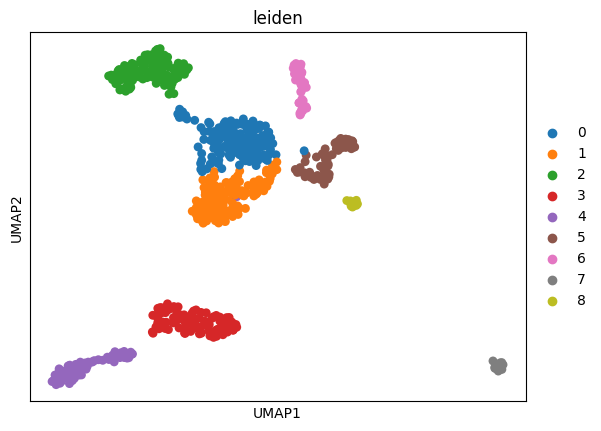

In [39]:
sc.pl.umap(adata, color=['leiden'])

In [40]:
# Find marker genes 
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')

/Users/iriskwon/.local/share/virtualenvs/STalign-hu3yymDJ/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/iriskwon/.local/share/virtualenvs/STalign-hu3yymDJ/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/iriskwon/.local/share/virtualenvs/STalign-hu3yymDJ/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/iriskwon/.local/share/virtualenvs/STalign-hu3yymDJ/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/iriskwon/.local/share/virtualenvs/STalign-hu3yymDJ/lib/python3.12/sit

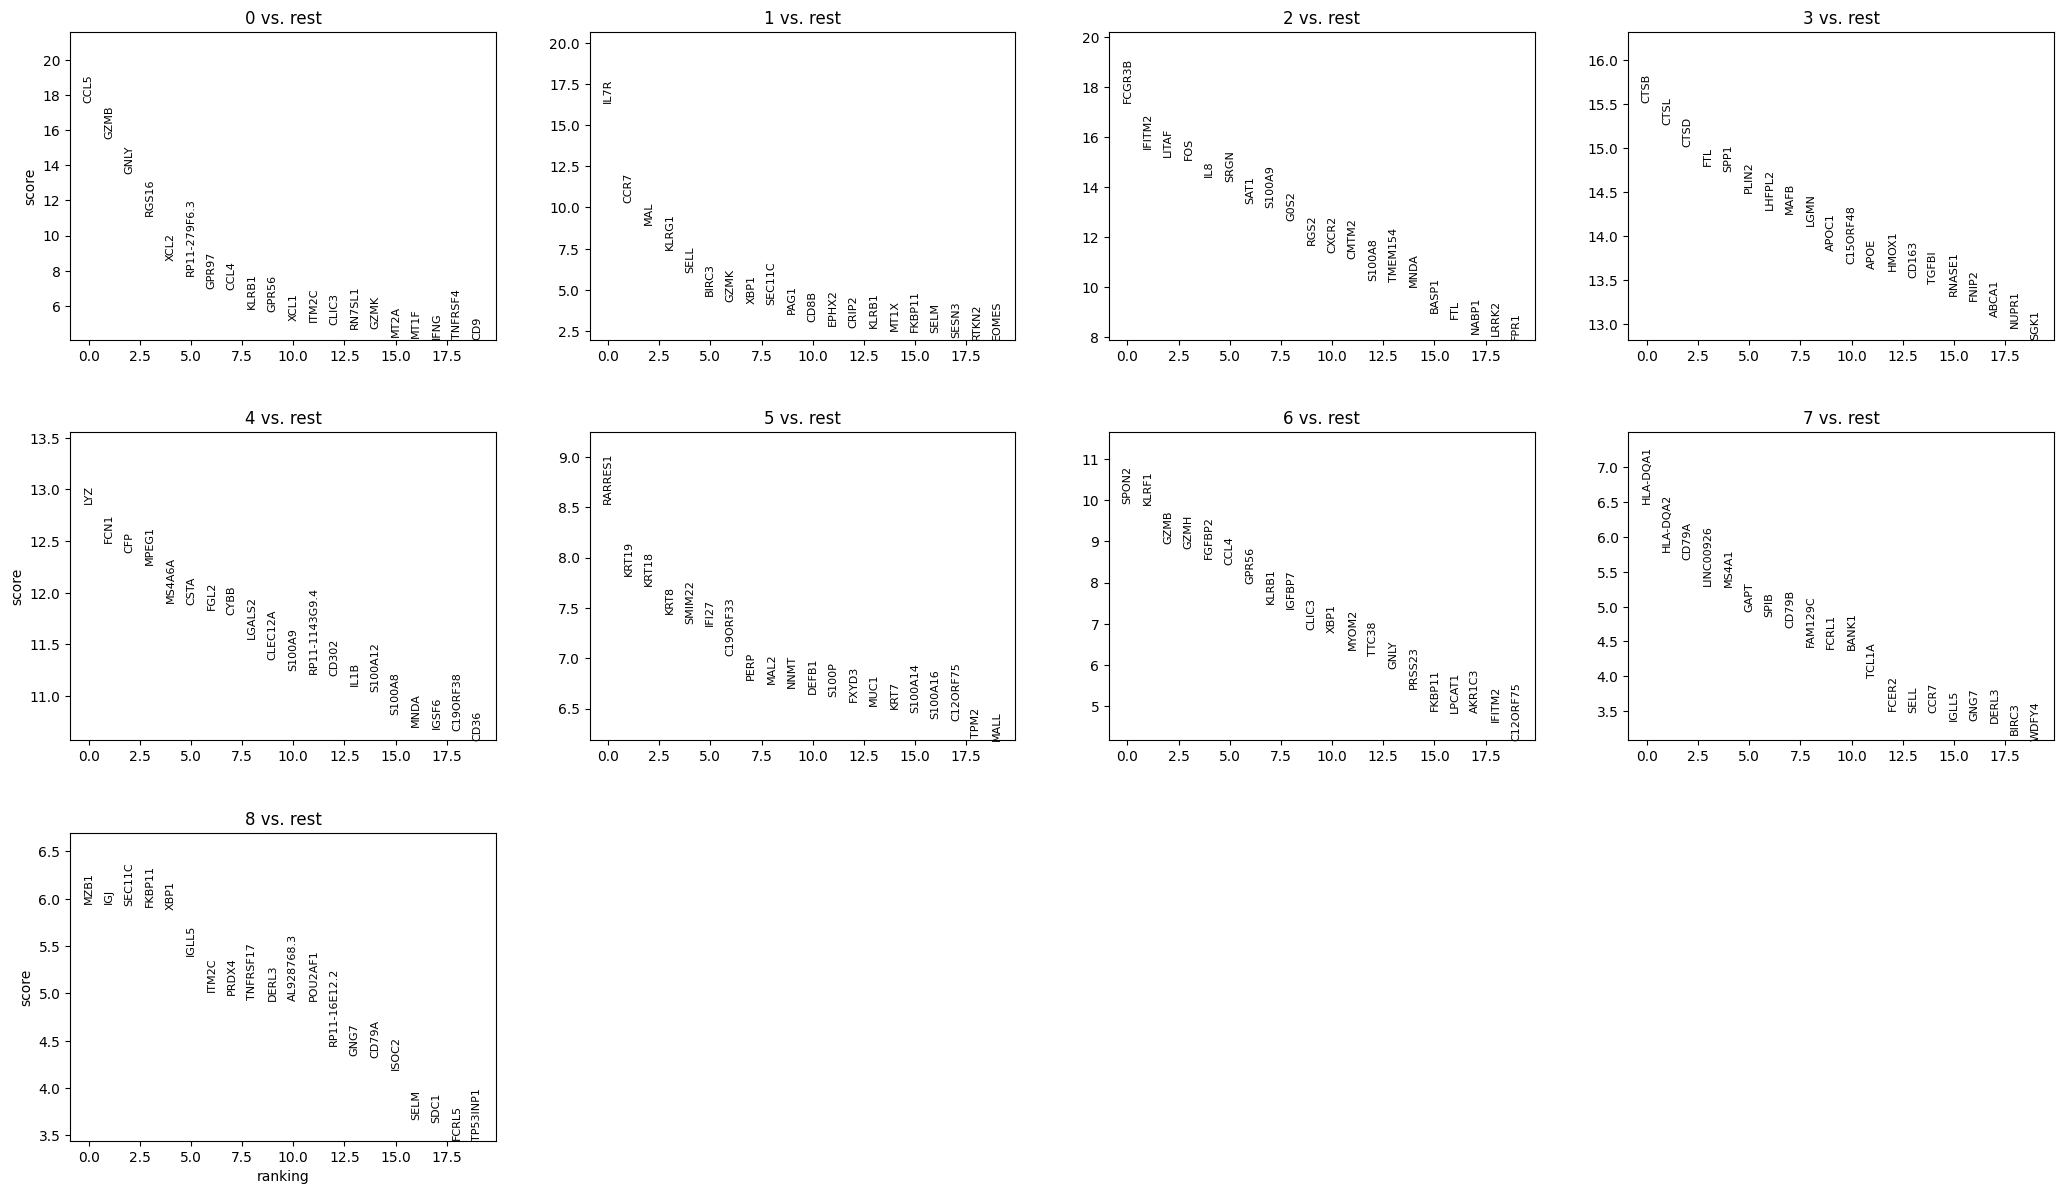

In [41]:
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)

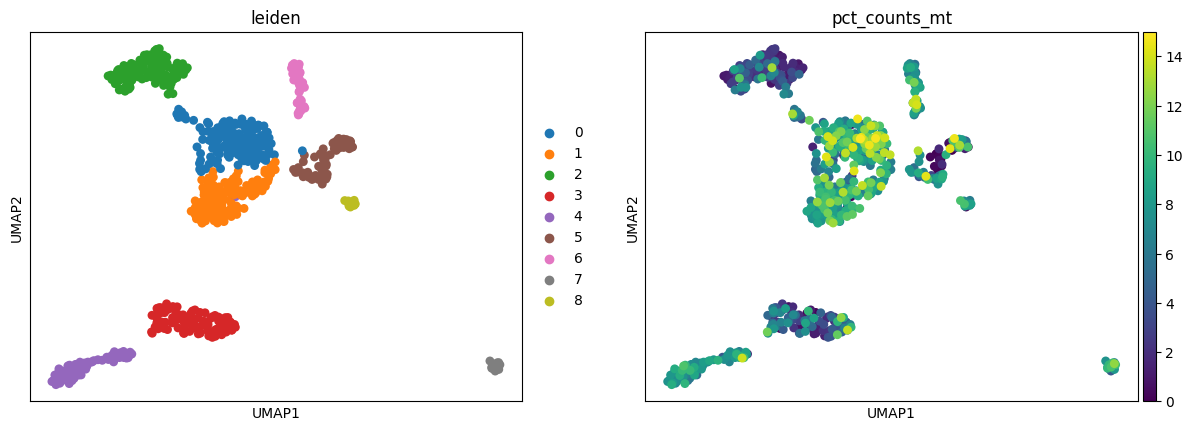

In [42]:
sc.pl.umap(adata, color=['leiden', 'pct_counts_mt'])

In [43]:
print(adata.obs.columns)

Index(['gsm', 'sample', 'condition', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes',
       'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes',
       'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt',
       'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo',
       'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes',
       'doublet_score', 'predicted_doublet', 'leiden_0.3', 'leiden_0.5',
       'leiden_0.8', 'leiden_1.0', 'leiden'],
      dtype='object')


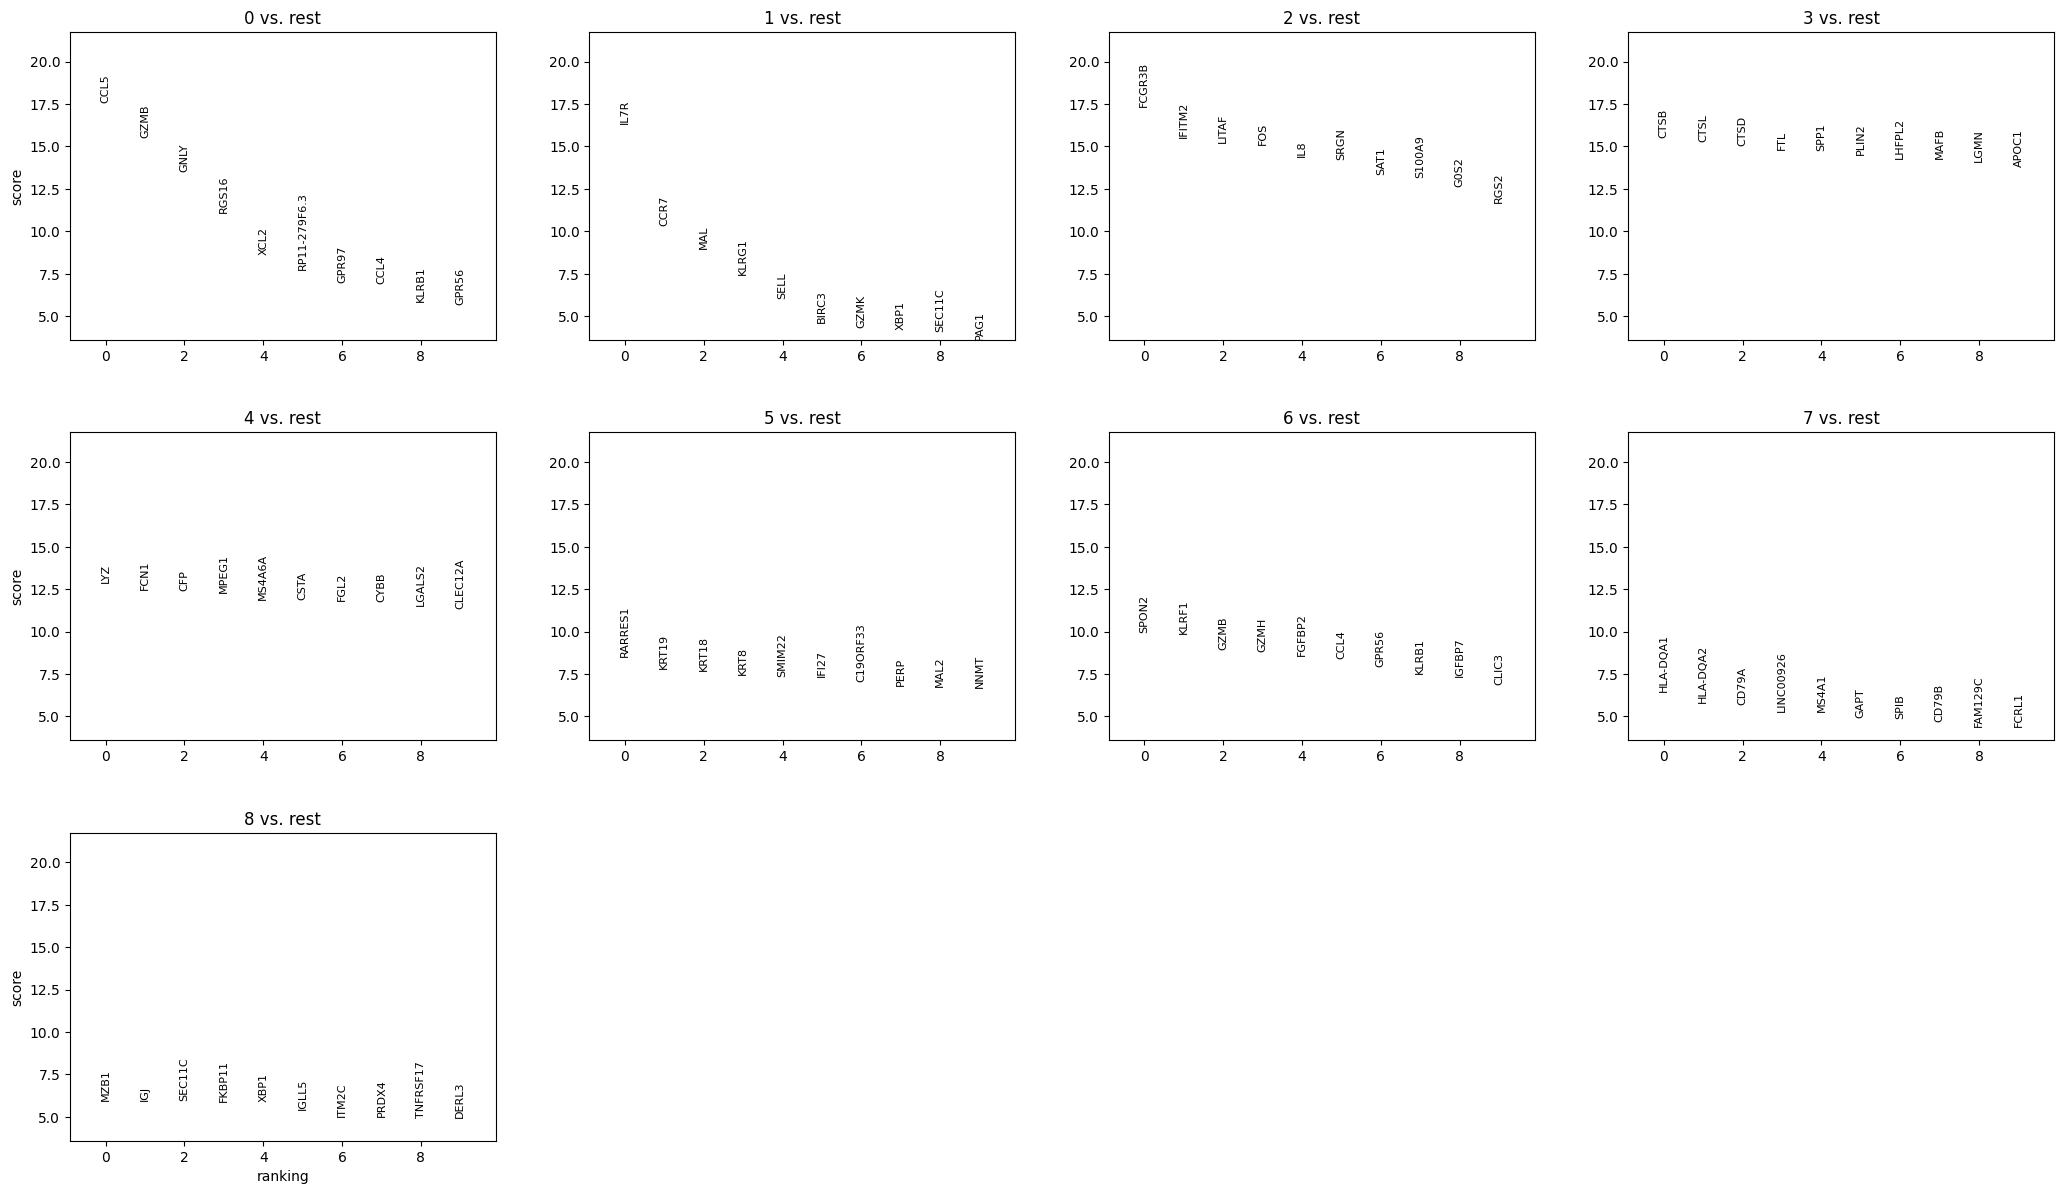

In [44]:
sc.pl.rank_genes_groups(adata, n_genes=10)

In [45]:
markers = pd.DataFrame(adata.uns['rank_genes_groups']['names'])
print(markers.head())

       0      1       2     3       4        5       6          7       8
0   CCL5   IL7R  FCGR3B  CTSB     LYZ  RARRES1   SPON2   HLA-DQA1    MZB1
1   GZMB   CCR7  IFITM2  CTSL    FCN1    KRT19   KLRF1   HLA-DQA2     IGJ
2   GNLY    MAL   LITAF  CTSD     CFP    KRT18    GZMB      CD79A  SEC11C
3  RGS16  KLRG1     FOS   FTL   MPEG1     KRT8    GZMH  LINC00926  FKBP11
4   XCL2   SELL     IL8  SPP1  MS4A6A   SMIM22  FGFBP2      MS4A1    XBP1


Guessing from ranked gene markers per cluster...

In [46]:
cluster_to_celltype = {
    '0': 'CD8+ T cells',
    '1': 'Naive / memory T cells',
    '2': 'Neutrophils',
    '3': 'Monocytes / macrophages',
    '4': 'Macrophages',
    '5': 'Tumor epithelial cells',
    '6': 'NK cells',
    '7': 'B cells',
    '8': 'Plasma cells'
}

adata.obs['cell_type'] = adata.obs['leiden'].map(cluster_to_celltype)

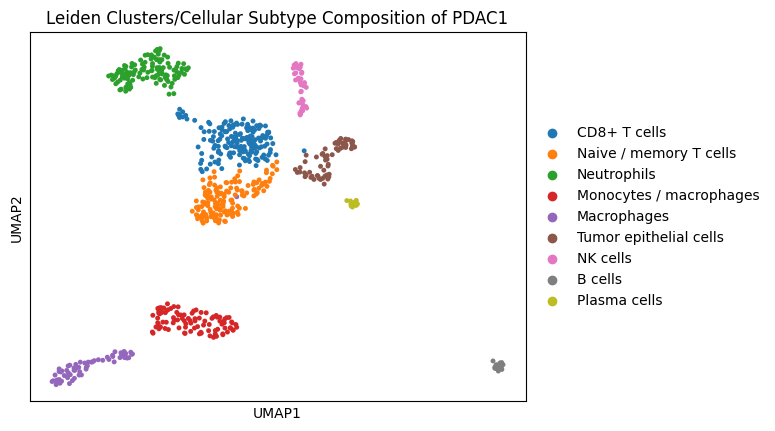

In [50]:
sc.pl.umap(
    adata,
    color=['cell_type'],
    size=50,
    title=[
        "Leiden Clusters/Cellular Subtype Composition of PDAC1"
    ]
)